# Setup and Data Preprocessing

### What this cell does:
Before training any machine learning models, we must prepare our data. This cell performs the following operations:
1. **Import Libraries:** Loads all necessary Python packages for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and machine learning (`scikit-learn`, `xgboost`).
2. **Load Data:** Reads the `diabetes_dataset.csv` file into a Pandas DataFrame.
3. **Data Imputation:** In medical data, values like Blood Pressure or BMI cannot physically be 0. These are missing values. The code isolates these specific columns and replaces any `0` with the median value of that column to prevent skewing our models.
4. **Train-Test Split:** Separates the target variable (`Outcome`) from the features. It then splits the data so that 80% is used for training the models and 20% is held back for testing. The `stratify=y` parameter ensures the ratio of diabetic to non-diabetic patients remains consistent in both splits.
5. **Feature Scaling:** Models that calculate distances (like KNN or SVM) require features to be on the same scale. We use `StandardScaler` to normalize the data. The scaler is saved as a `.pkl` file so future, unseen data can be scaled identically before predictions are made.
6. **Initialize Results Dictionary:** Creates an empty dictionary (`final_results`) to store the best accuracy scores for our final comparison.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# 1. Load Data
df = pd.read_csv("diabetes_dataset.csv")

# 2. Impute invalid 0 values
cols_to_replace = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_to_replace:
    df[col] = df[col].replace(0, df[col].median())

# 3. Split features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Scale Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Export the scaler for future predictions
joblib.dump(scaler, 'scaler.pkl')

# Dictionary to hold the final accuracies for comparison
final_results = {}

# Model 1: Logistic Regression

**Definition:** Logistic regression models the probability of a discrete outcome given an input variable. It uses a mathematical sigmoid function to classify data into a binary output (predicting 0 for non-diabetic or 1 for diabetic).

**Hyperparameter Tuned:** 
*   `C` (Inverse of regularization strength): Smaller values specify stronger regularization, which helps prevent the model from overfitting to the training data by penalizing overly complex patterns.

### What this code does:
1.  **Grid Search Setup:** Defines a dictionary of `C` values to test (`[0.01, 0.1, 1, 10, 100]`). It initializes `GridSearchCV` to run a 5-fold cross-validation, meaning it will test every `C` value 5 times on different slices of the training data to find the absolute best parameter.
2.  **Training:** Fits the grid search on the scaled training data.
3.  **Evaluation:** Extracts the best-performing model, makes predictions on the test set, and calculates the accuracy score. It saves this score to our `final_results` dictionary.
4.  **Export:** Uses `joblib` to save the optimal model weights into a file named `logistic_regression.pkl`.
5.  **Visualization:** Uses Seaborn to plot a Confusion Matrix, which visually breaks down the True Positives, True Negatives, False Positives, and False Negatives of our model's predictions.

Best Hyperparameters: {'C': 10}
Accuracy: 70.13%


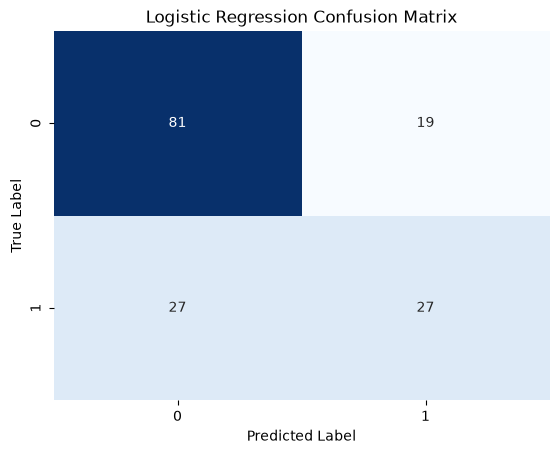

In [2]:
# Initialize Model and Grid
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), param_grid_lr, cv=5, scoring='accuracy')

# Train using GridSearchCV
grid_lr.fit(X_train_scaled, y_train)
best_lr = grid_lr.best_estimator_

# Predict and Evaluate
y_pred_lr = best_lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
final_results['Logistic Regression'] = acc_lr

# Save Model
joblib.dump(best_lr, 'logistic_regression.pkl')

# Output Results
print(f"Best Hyperparameters: {grid_lr.best_params_}")
print(f"Accuracy: {acc_lr*100:.2f}%")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Model 2: Support Vector Machine (Linear Kernel)

**Definition:** A Support Vector Machine (SVM) tries to find the optimal straight hyperplane (a flat boundary or line) that maximizes the margin (distance) between the two classes in the feature space.

**Hyperparameter Tuned:** 
*   `C` (Regularization parameter): It determines the penalty for misclassifying a data point during training. A lower `C` prioritizes a wider, softer margin, while a higher `C` aims for strict, correct classification of all training points (which can risk overfitting).

### What this code does:
Similar to the previous cell, this code sets up a `GridSearchCV` to test various values of `C`. It trains the linear SVM on the **scaled** data (crucial for SVMs), finds the best estimator, predicts the test set outcomes, saves the model to `svm_linear.pkl`, logs the accuracy, and generates a confusion matrix heatmap.

/home/minorin/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/minorin/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/minorin/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/minorin/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 a

Best Hyperparameters: {'C': 1}
Accuracy: 70.78%


/home/minorin/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


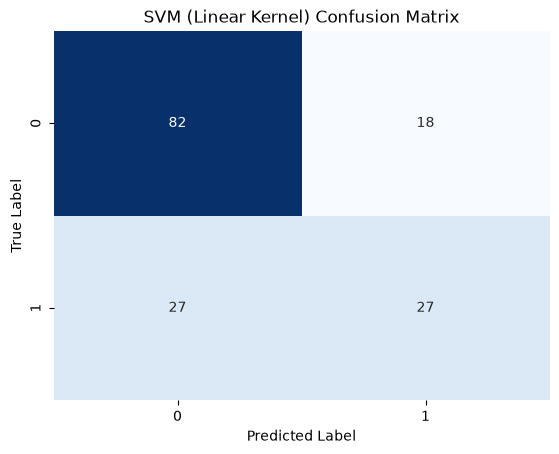

In [3]:
# Initialize Model and Grid
param_grid_svml = {'C': [0.01, 0.1, 1, 10]}
grid_svml = GridSearchCV(SVC(kernel='linear', random_state=42, probability=True), param_grid_svml, cv=5, scoring='accuracy')

# Train using GridSearchCV
grid_svml.fit(X_train_scaled, y_train)
best_svml = grid_svml.best_estimator_

# Predict and Evaluate
y_pred_svml = best_svml.predict(X_test_scaled)
acc_svml = accuracy_score(y_test, y_pred_svml)
final_results['SVM (Linear)'] = acc_svml

# Save Model
joblib.dump(best_svml, 'svm_linear.pkl')

# Output Results
print(f"Best Hyperparameters: {grid_svml.best_params_}")
print(f"Accuracy: {acc_svml*100:.2f}%")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svml)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('SVM (Linear Kernel) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Model 3: Support Vector Machine (RBF Kernel)

**Definition:** This is similar to the linear SVM, but it uses a Radial Basis Function (RBF) kernel. This kernel projects the data into a higher-dimensional space, allowing the model to draw complex, non-linear boundaries between the diabetic and non-diabetic classes.

**Hyperparameters Tuned:** 
*   `C`: The penalty for misclassification.
*   `gamma`: Determines the radius of influence of a single support vector. A higher gamma means data points must be very close to the boundary to influence it, leading to tighter, more complex boundaries.

### What this code does:
This code expands the grid search to test combinations of *both* `C` and `gamma`. It evaluates all possible pairs of these parameters using cross-validation on the scaled training data. Once the optimal combination is found, it evaluates the test set, saves the model as `svm_rbf.pkl`, and plots the confusion matrix to evaluate where the model made errors.

/home/minorin/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/minorin/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/minorin/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/minorin/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 a

Best Hyperparameters: {'C': 10, 'gamma': 0.01}
Accuracy: 71.43%


/home/minorin/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/minorin/anaconda3/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


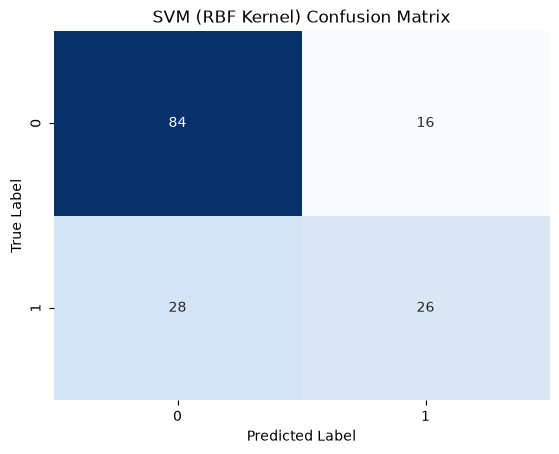

In [4]:
# Initialize Model and Grid
param_grid_svmr = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01, 0.1]}
grid_svmr = GridSearchCV(SVC(kernel='rbf', random_state=42, probability=True), param_grid_svmr, cv=5, scoring='accuracy')

# Train using GridSearchCV
grid_svmr.fit(X_train_scaled, y_train)
best_svmr = grid_svmr.best_estimator_

# Predict and Evaluate
y_pred_svmr = best_svmr.predict(X_test_scaled)
acc_svmr = accuracy_score(y_test, y_pred_svmr)
final_results['SVM (RBF)'] = acc_svmr

# Save Model
joblib.dump(best_svmr, 'svm_rbf.pkl')

# Output Results
print(f"Best Hyperparameters: {grid_svmr.best_params_}")
print(f"Accuracy: {acc_svmr*100:.2f}%")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svmr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('SVM (RBF Kernel) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Model 4: K-Nearest Neighbors (KNN)

**Definition:** KNN is a lazy learning algorithm. When asked to classify a new patient, it looks at the 'K' most mathematically similar patients (neighbors) in the training data and assigns the classification based on a majority vote.

**Hyperparameters Tuned:** 
*   `n_neighbors`: The number of nearest points (K) to check (e.g., check the 3, 5, 7, or 9 closest patients).
*   `weights`: 'uniform' gives all neighbors an equal vote; 'distance' gives closer neighbors a heavier, more important vote.

### What this code does:
This code tests different values for the number of neighbors and the weighting strategy. Because KNN relies entirely on calculating the mathematical distance between points, this code strictly uses the `X_train_scaled` data. It identifies the best configuration, scores the model, saves it to `knn.pkl`, and visually renders the true vs. predicted labels in a heatmap.

Best Hyperparameters: {'n_neighbors': 9, 'weights': 'distance'}
Accuracy: 69.48%


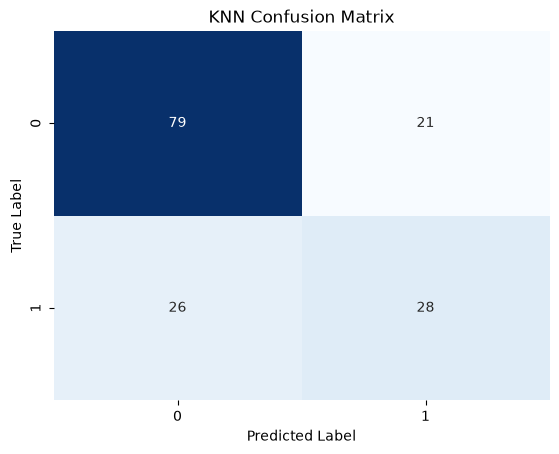

In [5]:
# Initialize Model and Grid
param_grid_knn = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy')

# Train using GridSearchCV
grid_knn.fit(X_train_scaled, y_train)
best_knn = grid_knn.best_estimator_

# Predict and Evaluate
y_pred_knn = best_knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
final_results['KNN'] = acc_knn

# Save Model
joblib.dump(best_knn, 'knn.pkl')

# Output Results
print(f"Best Hyperparameters: {grid_knn.best_params_}")
print(f"Accuracy: {acc_knn*100:.2f}%")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Model 5: Random Forest

**Definition:** Random Forest is an ensemble learning algorithm. It builds multiple, independent decision trees during training using random subsets of data and features. To make a final prediction, it merges the outputs of all the trees together to get a more accurate and stable result (a "majority vote" of trees).

**Hyperparameters Tuned:** 
*   `n_estimators`: The number of decision trees built in the forest.
*   `max_depth`: The maximum number of splits each tree is allowed to make. Capping this depth prevents the individual trees from memorizing the training data (overfitting).

### What this code does:
Unlike previous models, Decision Trees do not calculate distances, so **feature scaling is not strictly required**. Therefore, this code trains the grid search directly on the unscaled `X_train` data. It tests different forest sizes and tree depths, saves the best model to `random_forest.pkl`, logs the overall accuracy score, and plots the confusion matrix.

Best Hyperparameters: {'max_depth': 5, 'n_estimators': 100}
Accuracy: 74.03%


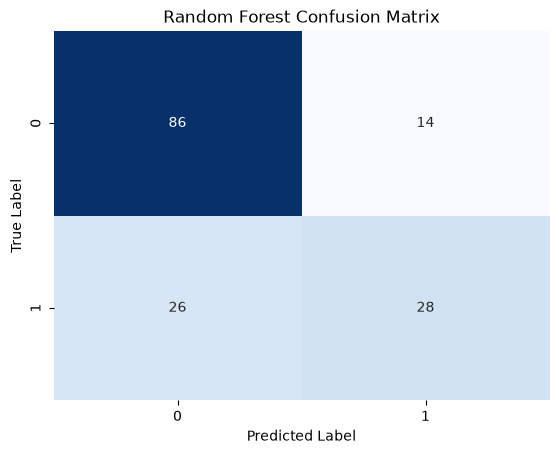

In [6]:
# Initialize Model and Grid (Tree models do not require scaled data)
param_grid_rf = {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')

# Train using GridSearchCV
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

# Predict and Evaluate
y_pred_rf = best_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
final_results['Random Forest'] = acc_rf

# Save Model
joblib.dump(best_rf, 'random_forest.pkl')

# Output Results
print(f"Best Hyperparameters: {grid_rf.best_params_}")
print(f"Accuracy: {acc_rf*100:.2f}%")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Model 6: XGBoost (Extreme Gradient Boosting)

**Definition:** XGBoost is a highly optimized, advanced ensemble method. Unlike Random Forest (which builds trees independently and in parallel), XGBoost builds trees *sequentially*. Each new tree is specifically designed to correct the mathematical errors (residuals) made by the combination of all previous trees.

**Hyperparameters Tuned:** 
*   `n_estimators`: The total number of sequential trees to build.
*   `learning_rate`: The step size shrinkage used to update the model. A smaller learning rate makes the model learn slower but often generalizes better.
*   `max_depth`: The maximum depth of the sequential trees.

### What this code does:
This code configures the XGBoost classifier (using `use_label_encoder=False` to comply with recent library updates) and tests a grid of trees, depths, and learning rates on the unscaled training data. It extracts the strongest performing boosting model, records its test accuracy, exports the weights to `xgboost.pkl`, and displays the confusion matrix.

Best Hyperparameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Accuracy: 72.73%


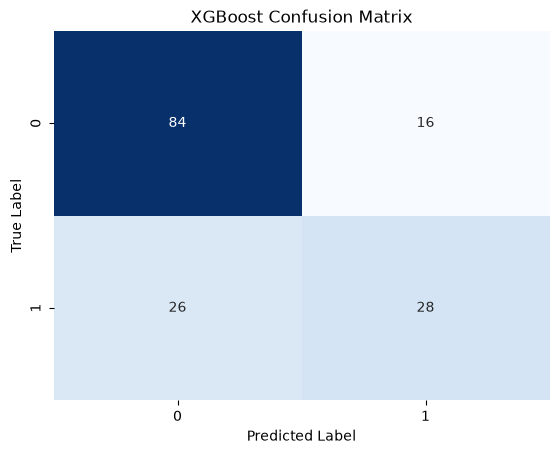

In [7]:
# Initialize Model and Grid
param_grid_xgb = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5]}
grid_xgb = GridSearchCV(xgb.XGBClassifier(eval_metric='logloss', random_state=42), param_grid_xgb, cv=5, scoring='accuracy')

# Train using GridSearchCV
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

# Predict and Evaluate
y_pred_xgb = best_xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
final_results['XGBoost'] = acc_xgb

# Save Model
joblib.dump(best_xgb, 'xgboost.pkl')

# Output Results
print(f"Best Hyperparameters: {grid_xgb.best_params_}")
print(f"Accuracy: {acc_xgb*100:.2f}%")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Final Model Comparison

### What this code does:
Now that all models have been tuned, trained, and evaluated, we need to determine which one performed the best. This cell performs the following:
1.  **Data Structuring:** It takes the `final_results` dictionary (which collected the accuracy scores from every previous cell) and converts it into a structured Pandas DataFrame.
2.  **Formatting:** It multiplies the raw decimal accuracies by 100 to convert them to percentages and sorts the table from highest accuracy to lowest.
3.  **Visualization:** Uses Seaborn to plot a horizontal bar chart. Crucially, it dynamically zooms the x-axis to tightly wrap the minimum and maximum accuracy scores (rather than starting at 0). It also loops through the chart objects to append the exact percentage label to the end of each bar, making the performance gaps explicitly clear.

=== Final Model Comparison ===


,Model,Accuracy
0,Random Forest,74.025974
1,XGBoost,72.727273
2,SVM (RBF),71.428571
3,SVM (Linear),70.779221
4,Logistic Regression,70.129870
5,KNN,69.480519


/tmp/ipykernel_156483/2866422426.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')


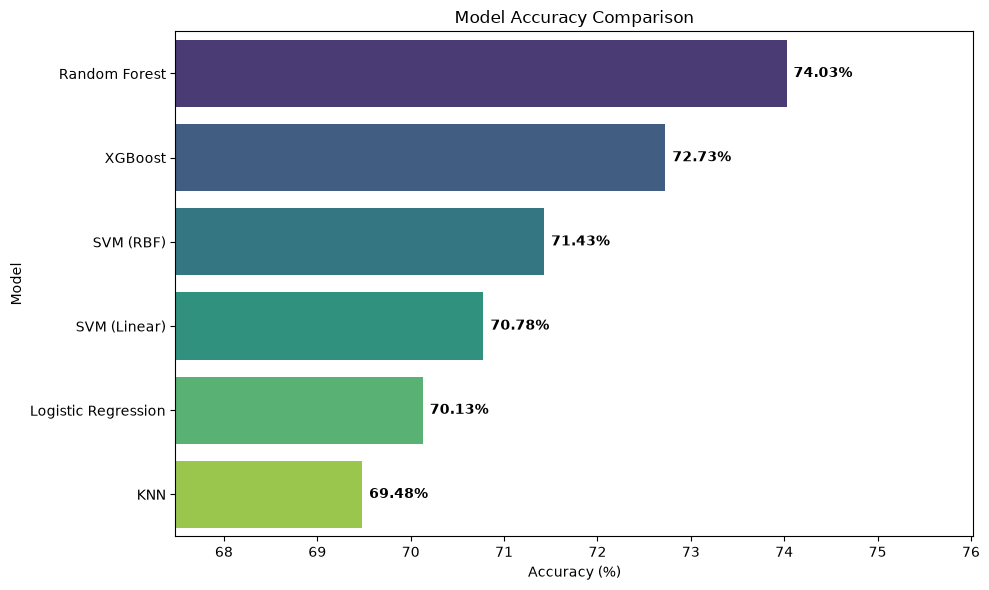

In [8]:
# Compare all models
results_df = pd.DataFrame(list(final_results.items()), columns=['Model', 'Accuracy'])
results_df['Accuracy'] = results_df['Accuracy'] * 100

# Sort the values from best to worst
results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Display tabular data
print("=== Final Model Comparison ===")
display(results_df)

# Plot comparison
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')

# Dynamically zoom in on the x-axis to highlight differences
min_acc = results_df['Accuracy'].min()
max_acc = results_df['Accuracy'].max()
plt.xlim(min_acc - 2, max_acc + 2) 

# Add text labels on the bars
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}%', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), textcoords='offset points',
                fontweight='bold')

plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy (%)')
plt.tight_layout()
plt.show()